In [1]:
# !pip install visualkeras


In [2]:
# !pip install visualkeras pydot


In [3]:
# !pip install pydot graphviz


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization, Input, Reshape, multiply
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
import visualkeras

# SE block definition
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling2D()(input_tensor)
    se = Reshape((1, 1, channels))(se)
    se = Dense(channels // reduction, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    return multiply([input_tensor, se])

# Paths to your dataset
base_dir = r'C:\Users\KIIT\Desktop\malaria'

# Image Data Generators with enhanced Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    shear_range=0.2,
    zoom_range=0.2,  # Reduced zoom for finer adjustments
    rotation_range=20,  # Reduced rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]  # New brightness adjustment
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

# Load images from directory structure
train_generator = train_datagen.flow_from_directory(
    directory=f'{base_dir}/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    directory=f'{base_dir}/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build the Model with Xception Base
base_model = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the first 50 layers for better flexibility
for layer in base_model.layers[:50]:
    layer.trainable = False

# Build the new model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)

# Insert SE block after the Xception base
x = se_block(x)

# Global Average Pooling and Classifier
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

# Complete model
model = Model(inputs, outputs)

# Compile with fixed learning rate for stable training
initial_learning_rate = 1e-4  # Adjusted for finer control
model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define Callbacks with adjusted parameters
early_stopping = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stopping, reduce_lr]
)

Found 22048 images belonging to 2 classes.
Found 2755 images belonging to 2 classes.
Epoch 1/20


C:\Users\KIIT\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


689/689 ━━━━━━━━━━━━━━━━━━━━ 4430s 6s/step - accuracy: 0.8766 - loss: 0.7668 - val_accuracy: 0.9600 - val_loss: 0.5230 - learning_rate: 1.0000e-04
Epoch 2/20


C:\Users\KIIT\anaconda3\Lib\contextlib.py:155: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.6667 - val_loss: 1.5661 - learning_rate: 1.0000e-04
Epoch 3/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4616s 7s/step - accuracy: 0.9381 - loss: 0.5595 - val_accuracy: 0.9666 - val_loss: 0.4550 - learning_rate: 1.0000e-04
Epoch 4/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 383us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.4950 - learning_rate: 1.0000e-04
Epoch 5/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4493s 7s/step - accuracy: 0.9457 - loss: 0.4912 - val_accuracy: 0.9688 - val_loss: 0.3900 - learning_rate: 1.0000e-04
Epoch 6/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 405us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.2955 - learning_rate: 1.0000e-04
Epoch 7/20
689/689 ━━━━━━━━━━━━━━━━━━━━ 4377s 6s/step - accuracy: 0.9503 - loss: 0.4270 - val_accuracy: 0.9698 - val_loss: 0.3450 - learning_rate: 1.0000e-04
Epoch 8/20
689/689 ━━━━━━━━━━━━━━━━━━━━

C:\Users\KIIT\anaconda3\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


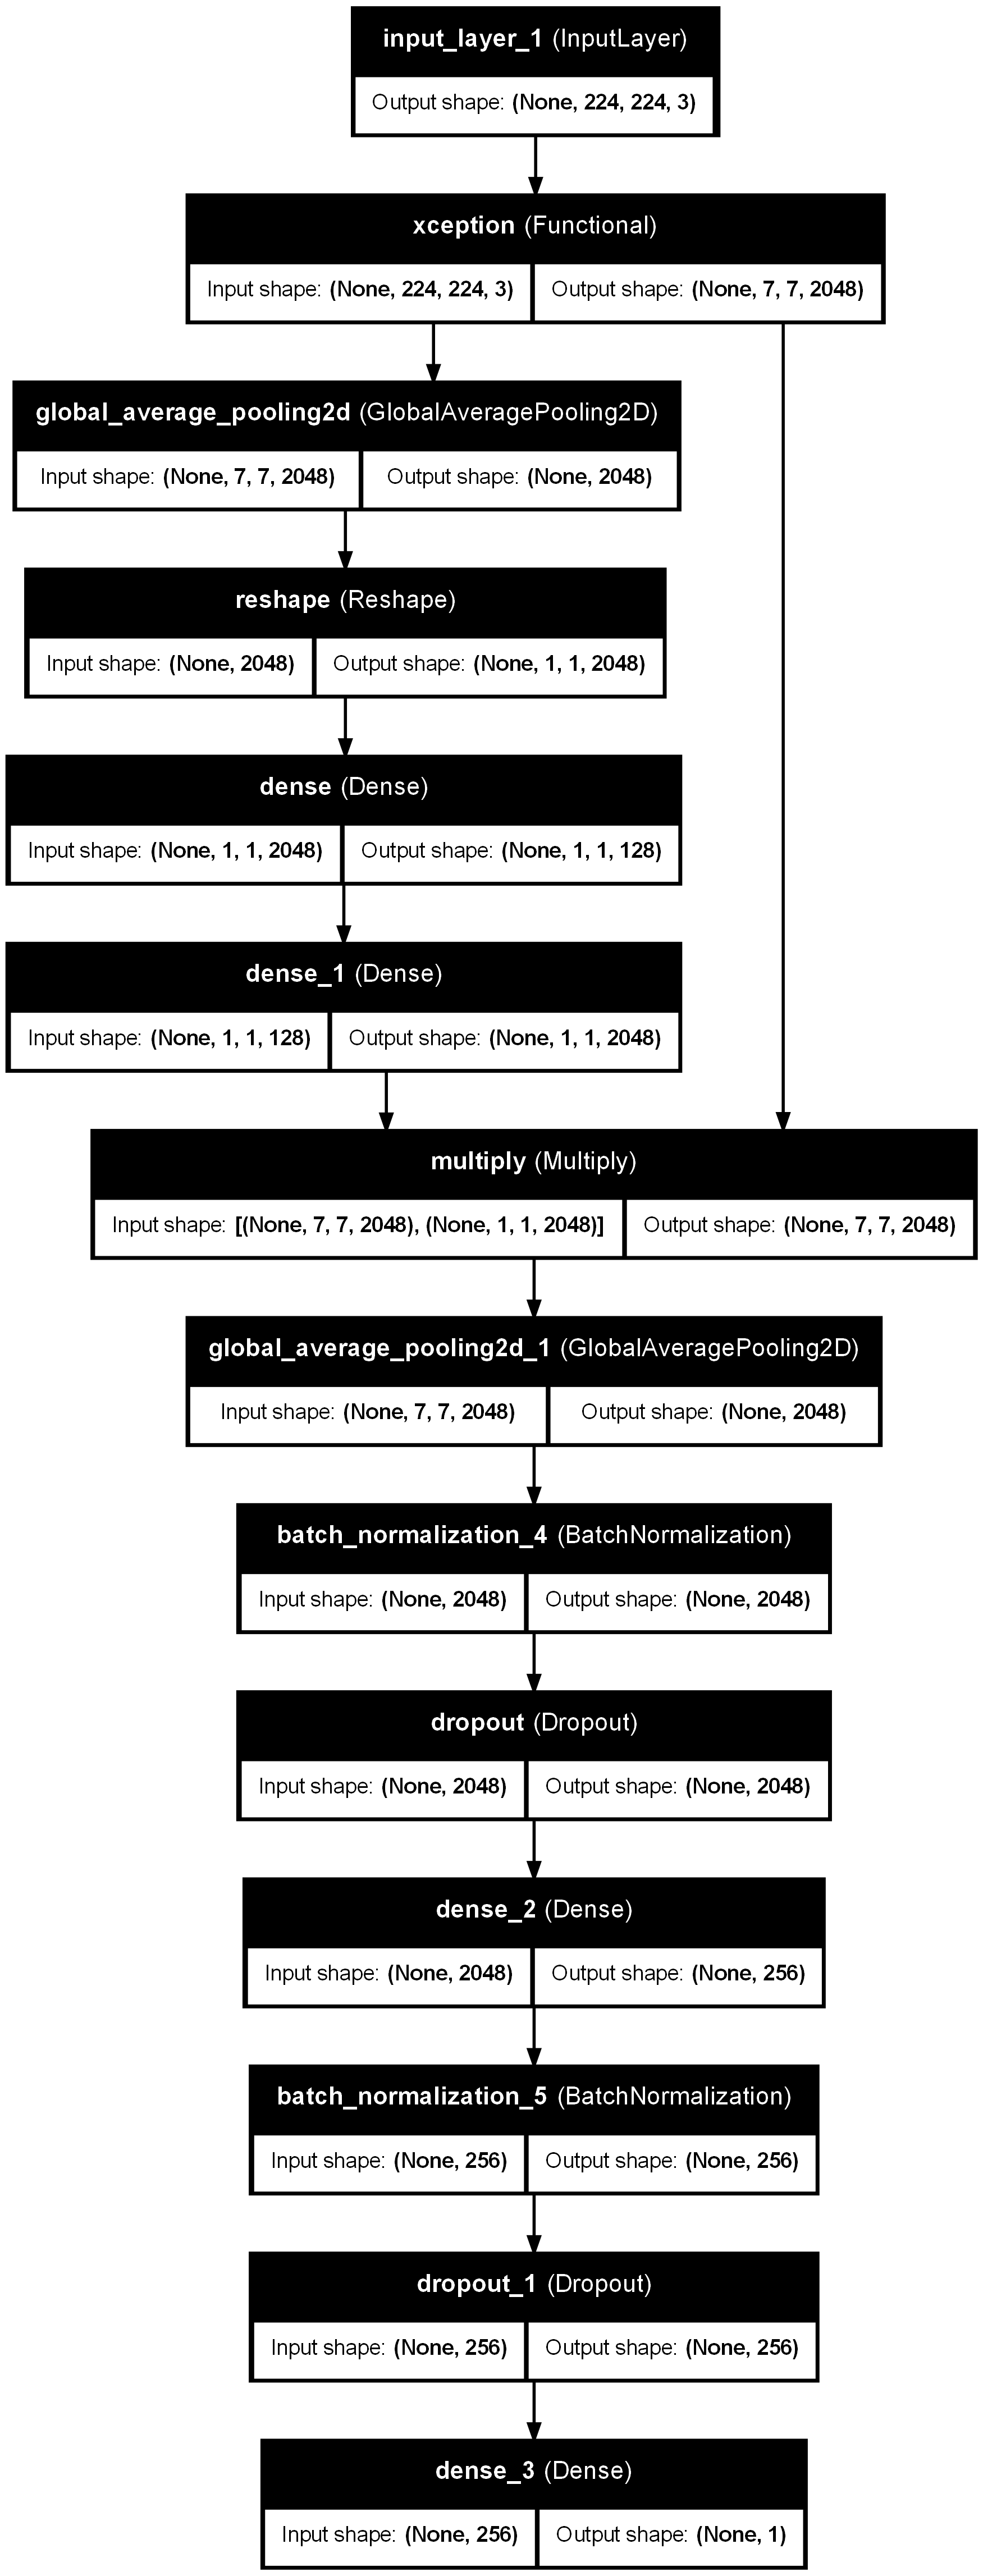

In [5]:
# Save the model in .h5 format for Netron visualization
model.save('xception_proposed_model.h5')

# Generate Visualkeras Model Plot
visualkeras.layered_view(model, legend=True).show()

# Generate Keras Model Plot (Plot_model)
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

# Netron: Use the saved .h5 file ('xception_model.h5') for visualization

In [7]:
# Generate Visualkeras Model Plot
visualkeras.layered_view(model, legend=True).show()